<a href="https://colab.research.google.com/github/Aman-5011/ML_100days_campusx/blob/main/day%2055%20Regularised-linear-models/ridge_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes
data=load_diabetes()

In [3]:
print(data.DESCR)
#when we write only data.DESCR than it just show a paragraph bcz it is just a long string
#but when we print it = it become organized bcz Internally, it actually contains newline characters (\n)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
x=data.data
y=data.target

In [7]:
from sklearn.model_selection import train_test_split
xtr,xts,ytr,yts=train_test_split(x,y,test_size=0.2,random_state=45)

In [8]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(xtr,ytr)

LinearRegression()

In [9]:
print(lr.coef_)
print(lr.intercept_)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [10]:
y_pred=lr.predict(xts)

In [12]:
from sklearn.metrics import r2_score,mean_squared_error
print("R2 Score: ",r2_score(yts,y_pred))
print("RMSE",np.sqrt(mean_squared_error(yts,y_pred)))

R2 Score:  0.5188113124539249
RMSE 48.72713760953253


In [13]:
from sklearn.linear_model import Ridge
r=Ridge(alpha=100000)

In [14]:
r.fit(xtr,ytr)
print(r.coef_)
print(r.intercept_)

[ 0.00260126  0.00057066  0.00776597  0.0060976   0.00233864  0.00184724
 -0.00513942  0.0052716   0.00734598  0.00528629]
151.83287930791352


In [15]:
y_pred1=r.predict(xts)
print("R2 Score: ",r2_score(yts,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(yts,y_pred1)))

R2 Score:  -0.00042490200441935855
RMSE 70.25956272917782


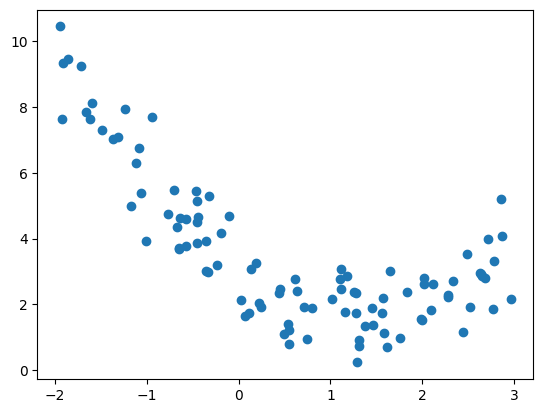

In [16]:
m=100
x1=5*np.random.rand(m,1)-2
x2=0.7*x1**2-2*x1+3+np.random.randn(m,1)
plt.scatter(x1,x2)
plt.show()

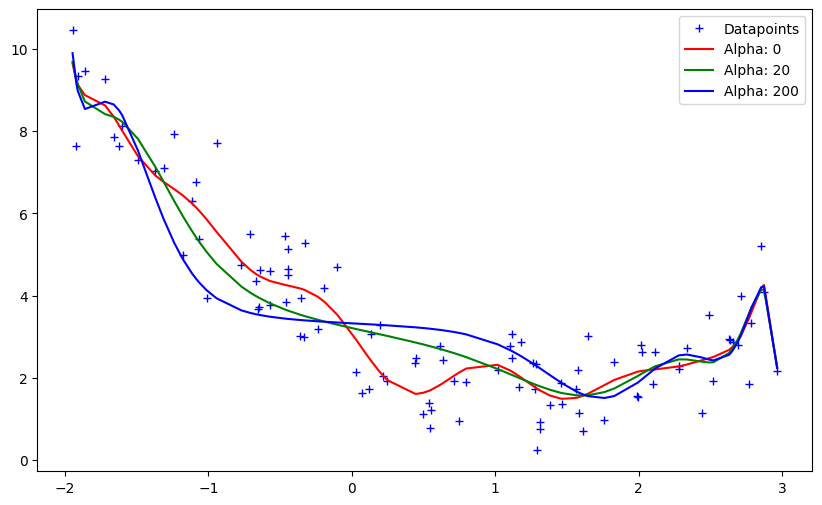

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()
